Hasil Fuzzifikasi Area: [0.25 0.75 0.  ]
Hasil Fuzzifikasi Daya: [0.         0.33333333 0.33333333]
------------------------------
Input Area: 35 m2
Input Daya: 3500 Watt
Rekomendasi Harga Paket (Sugeno): Rp 19.29 Juta


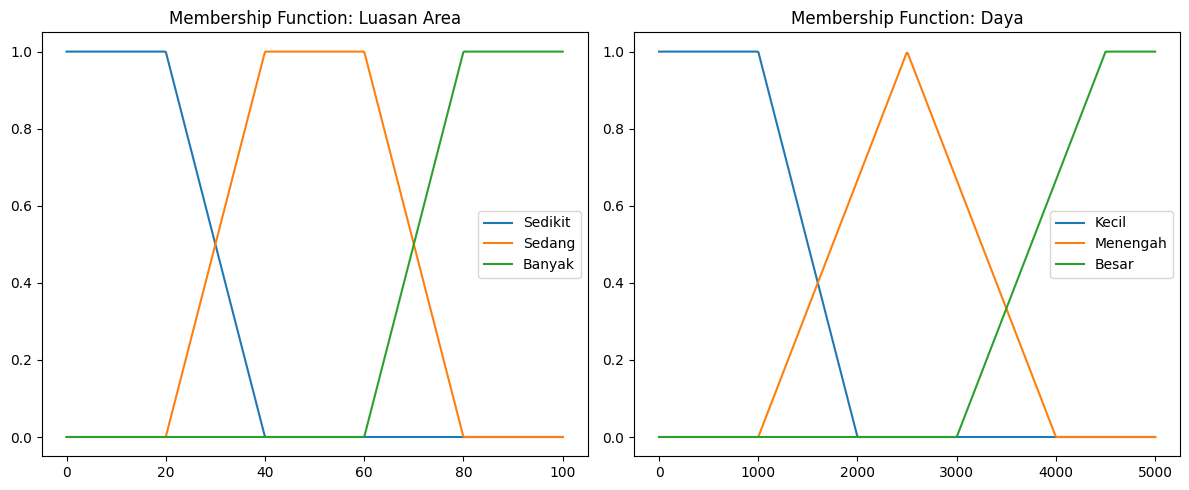

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def trapesium_atau_segitiga(x, a, b, c, d):
    """
    Fungsi keanggotaan universal (bisa jadi segitiga atau trapesium)
    a, d: kaki bawah
    b, c: puncak (jika b=c maka jadi segitiga)
    """
    return max(min((x - a) / (b - a) if b > a else 1,
                   1,
                   (d - x) / (d - c) if d > c else 1), 0)

# 1. FUZZIFIKASI AREA (Contoh Range: 0 - 100 m2)
def fuzifikasi_area(x):
    sedikit = trapesium_atau_segitiga(x, 0, 0, 20, 40)
    sedang = trapesium_atau_segitiga(x, 20, 40, 60, 80)
    banyak = trapesium_atau_segitiga(x, 60, 80, 100, 100)
    return np.array([sedikit, sedang, banyak])

# 2. FUZZIFIKASI DAYA (Contoh Range: 0 - 5000 Watt)
def fuzifikasi_daya(x):
    kecil = trapesium_atau_segitiga(x, 0, 0, 1000, 2000)
    menengah = trapesium_atau_segitiga(x, 1000, 2500, 2500, 4000)
    besar = trapesium_atau_segitiga(x, 3000, 4500, 5000, 5000)
    return np.array([kecil, menengah, besar])

# 3. DEFINISI SINGLETON OUTPUT (Sugeno Orde-0)
# Kita tentukan nilai konstan untuk tiap kelas paket (dalam jutaan rupiah misalnya)
BASIC = 5      # Juta
PREMIUM = 15   # Juta
PLATINUM = 30  # Juta

# 4. RULE BASE (Matriks 3x3: Baris=Area, Kolom=Daya)
# Area: [Sedikit, Sedang, Banyak]
# Daya: [Kecil, Menengah, Besar]
# Contoh Aturan: IF PV sedikit AND Daya besar THEN Paket = Premium
rules = np.array([
    [BASIC,    PREMIUM,  PREMIUM],  # Area Sedikit [Daya K, M, B]
    [BASIC,    PREMIUM,  PLATINUM], # Area Sedang  [Daya K, M, B]
    [PREMIUM,  PLATINUM, PLATINUM]  # Area Banyak  [Daya K, M, B]
])

# 5. INFERENCE & DEFUZZIFIKASI (Weighted Average)
def hitung_harga_paket(area_val, daya_val):
    fuzzy_area = fuzifikasi_area(area_val)
    fuzzy_daya = fuzifikasi_daya(daya_val)

    num = 0
    denum = 0

    print(f"Hasil Fuzzifikasi Area: {fuzzy_area}")
    print(f"Hasil Fuzzifikasi Daya: {fuzzy_daya}")
    print("-" * 30)

    for i, w_area in enumerate(fuzzy_area):
        for j, w_daya in enumerate(fuzzy_daya):
            # Menggunakan operator AND (MIN)
            weight = min(w_area, w_daya)
            if weight > 0:
                z = rules[i][j]
                num += weight * z
                denum += weight

    if denum == 0: return 0
    return num / denum

# --- EKSEKUSI ---
input_area = 35  # m2
input_daya = 3500 # Watt

harga_akhir = hitung_harga_paket(input_area, input_daya)

print(f"Input Area: {input_area} m2")
print(f"Input Daya: {input_daya} Watt")
print(f"Rekomendasi Harga Paket (Sugeno): Rp {harga_akhir:.2f} Juta")

# --- VISUALISASI ---
def plot_membership():
    x_area = np.linspace(0, 100, 500)
    x_daya = np.linspace(0, 5000, 500)

    y_area = np.array([fuzifikasi_area(v) for v in x_area])
    y_daya = np.array([fuzifikasi_daya(v) for v in x_daya])

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(x_area, y_area[:, 0], label="Sedikit")
    plt.plot(x_area, y_area[:, 1], label="Sedang")
    plt.plot(x_area, y_area[:, 2], label="Banyak")
    plt.title("Membership Function: Luasan Area")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(x_daya, y_daya[:, 0], label="Kecil")
    plt.plot(x_daya, y_daya[:, 1], label="Menengah")
    plt.plot(x_daya, y_daya[:, 2], label="Besar")
    plt.title("Membership Function: Daya")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_membership()